# Movimiento Geométrico Browniano: ¿describe a SPY?

**¿Es consistente el S&P 500 con un GBM de parámetros constantes?**

El movimiento geométrico browniano (GBM) es el modelo de referencia de Black–Scholes–Merton: el
precio $S_t$ evoluciona según

$$d(\ln S_t) = \left(\mu - \tfrac{1}{2}\sigma^2\right) dt + \sigma\, dW_t
\qquad\Longrightarrow\qquad
S_t = S_0 \exp\!\Big(\big(\mu-\tfrac{\sigma^2}{2}\big)t+\sigma W_t\Big),$$

con $W_t$ un proceso de Wiener y $\mu$, $\sigma$ constantes. Trabajando con los log-retornos
$x_t = \ln(S_t/S_{t-1})$, el Lema de Itô da la distribución exacta en cada paso:

$$x_t \sim \mathcal{N}\!\left(\big(\mu - \tfrac{1}{2}\sigma^2\big)\Delta t,\; \sigma^2 \Delta t\right).$$

Este notebook calibra $\mu$ y $\sigma$ con datos in-sample y pone a prueba, out-of-sample, las dos
hipótesis que sostienen al modelo:

| # | Se pone a prueba | Sección |
|---|-------------------|---------|
| 1 | La distribución exacta de $S_t$ contra la trayectoria realizada | [4](#4-distribución-exacta-y-validación-fan-chart) |
| 2 | Cobertura empírica de las bandas de confianza | [5](#5-cobertura-empírica-de-las-bandas) |
| 3 | Constancia de $\mu$ y $\sigma$ en el tiempo | [6](#6-estacionariedad-mu-y-sigma-en-ventana-móvil) |
| 4 | Independencia entre drift y volatilidad (efecto apalancamiento) | [7](#7-drift-vs-volatilidad) |

> Los *stylized facts* de los retornos (colas pesadas, asimetría, clustering de volatilidad) se
> caracterizan en detalle en [`SPY_caracterizacion.ipynb`](SPY_caracterizacion.ipynb); acá se
> usan sólo en la medida en que son necesarios para falsear el GBM.

### Cómo correrlo

```bash
pip install -r requirements.txt
jupyter lab GeometricMotion.ipynb   # Kernel > Restart & Run All
```

## 1. Configuración

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import numpy.ma as ma
import scipy.stats as stats
import yfinance as yf
from arch.bootstrap import MovingBlockBootstrap

# --- Parámetros del análisis ------------------------------------------------
TICKER        = "SPY"
START         = "1993-01-01"    # mismo rango que SPY_caracterizacion.ipynb
END           = "2026-01-01"
SPLIT_DATE    = "2016-01-01"    # fin del entrenamiento (in-sample) / inicio del test
TRADING_DAYS  = 252
ROLLING_WINDOW = 60              # ~3 meses, para la Sección 6
BLOCK_SIZE    = 10               # bootstrap por bloques, en días hábiles
N_BOOT        = 3_000
ALPHA         = 0.05
BAND_LEVELS   = (0.025, 0.10, 0.25, 0.50, 0.75, 0.90, 0.975)  # cuantiles del fan chart
SEED          = 42
DATA_DIR      = Path("data")

np.random.seed(SEED)

# --- Estilo de figuras (igual que SPY_caracterizacion.ipynb) ---------------
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
    "legend.frameon": False,
})

In [3]:
import sys, matplotlib, scipy, arch

for mod in (np, pd, scipy, matplotlib, arch, yf):
    print(f"{mod.__name__:<12} {mod.__version__}")
print(f"{'python':<12} {sys.version.split()[0]}")

numpy        2.4.6
pandas       3.0.5
scipy        1.17.1
matplotlib   3.11.1
arch         8.0.0
yfinance     1.6.0
python       3.11.15


## 2. Datos

Mismo loader cacheado que en `SPY_caracterizacion.ipynb`, con los mismos parámetros de ticker y
ventana: ambos notebooks comparten el archivo en `data/` en lugar de descargar la serie dos veces.

In [4]:
def load_prices(ticker: str = TICKER,
                start: str = START,
                end: str = END,
                cache_dir: Path = DATA_DIR,
                refresh: bool = False) -> pd.Series:
    """Precio de cierre ajustado, con caché local en CSV."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = cache_dir / f"{ticker}_{start}_{end}.csv"

    if cache.exists() and not refresh:
        px = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze("columns")
    else:
        raw = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
        px = raw["Adj Close"].dropna().squeeze()
        px.to_csv(cache)

    px.name = f"{ticker} Adj Close"
    return px


price = load_prices()
log_ret = np.log(price / price.shift(1)).dropna()

# Split in-sample / out-of-sample. `asof` ubica la fecha hábil más cercana.
split_idx = price.index.asof(pd.Timestamp(SPLIT_DATE))
train_ret  = log_ret.loc[:split_idx]
test_price = price.loc[split_idx:]          # la "realidad" contra la que se valida
S0 = float(price.loc[split_idx])

print(f"Serie completa   : {price.index[0]:%Y-%m-%d} a {price.index[-1]:%Y-%m-%d}  "
      f"({len(price):,} precios)")
print(f"Entrenamiento    : {train_ret.index[0]:%Y-%m-%d} a {train_ret.index[-1]:%Y-%m-%d}  "
      f"({len(train_ret):,} retornos)")
print(f"Validación (OOS) : {test_price.index[0]:%Y-%m-%d} a {test_price.index[-1]:%Y-%m-%d}  "
      f"({len(test_price):,} precios)")
print(f"S0 (precio de arranque de la simulación): {S0:.2f} USD")

Serie completa   : 1993-01-29 a 2025-12-31  (8,288 precios)
Entrenamiento    : 1993-02-01 a 2015-12-31  (5,773 retornos)
Validación (OOS) : 2015-12-31 a 2025-12-31  (2,515 precios)
S0 (precio de arranque de la simulación): 171.87 USD


## 3. Calibración (MLE + bootstrap por bloques)

Los estimadores de máxima verosimilitud para un GBM de parámetros constantes son la media y el
desvío muestral de los log-retornos, anualizados. El drift *geométrico* $\tilde\mu = \mathbb{E}[x_t]/\Delta t$
es lo que se estima directamente; el drift *aritmético* $\mu$ (el que aparece en la SDE) requiere la
corrección de Itô $\mu = \tilde\mu + \sigma^2/2$.

Como en `SPY_caracterizacion.ipynb`, el intervalo de confianza se calcula con un *moving block
bootstrap* en lugar de la fórmula asintótica $\mathrm{SE}(\hat\sigma)\approx\hat\sigma/\sqrt{2N}$:
esa fórmula asume retornos i.i.d., que es exactamente la hipótesis que este notebook está poniendo
a prueba, así que usarla para el propio intervalo de confianza sería circular.

In [5]:
def block_bootstrap_ci(x: np.ndarray,
                       func,
                       block_size: int = BLOCK_SIZE,
                       reps: int = N_BOOT,
                       alpha: float = ALPHA) -> tuple[np.ndarray, np.ndarray]:
    """Estimación puntual e IC percentil vía moving block bootstrap."""
    x = np.asarray(x, dtype=float)
    bs = MovingBlockBootstrap(block_size, x=x)
    ci = bs.conf_int(func, reps=reps, method="percentile", size=1 - alpha)
    return np.atleast_1d(func(x)), np.asarray(ci)


def gbm_mle_params(x: np.ndarray) -> np.ndarray:
    """[drift geométrico, sigma, drift aritmético] anualizados, MLE de un GBM constante."""
    x = np.asarray(x, dtype=float)
    drift_geo = x.mean() * TRADING_DAYS
    sigma = x.std(ddof=1) * np.sqrt(TRADING_DAYS)
    mu = drift_geo + 0.5 * sigma ** 2          # corrección de Itô
    return np.array([drift_geo, sigma, mu])


(point, ci) = block_bootstrap_ci(train_ret.values, gbm_mle_params)
drift_geo, sigma_est, mu_est = point
names = ["Drift geométrico (μ̃)", "Sigma (σ)", "Drift aritmético (μ)"]

for name, val, lo, hi in zip(names, point, ci[0], ci[1]):
    print(f"{name:<24}: {val:7.4f}   (IC {1-ALPHA:.0%}: [{lo:.4f}, {hi:.4f}])")

Drift geométrico (μ̃)   :  0.0857   (IC 95%: [0.0178, 0.1544])
Sigma (σ)               :  0.1890   (IC 95%: [0.1747, 0.2052])
Drift aritmético (μ)    :  0.1036   (IC 95%: [0.0366, 0.1715])


## 4. Distribución exacta y validación (fan chart)

Con $\mu$ y $\sigma$ calibrados sobre el período de entrenamiento, la distribución de $S_t$ para
$t>$ fecha de corte es exacta —no hace falta simular Monte Carlo—, porque el Lema de Itô ya la da
en forma cerrada:

$$\ln S_t \sim \mathcal{N}\big(\ln S_0 + \tilde\mu\, t,\; \sigma^2 t\big), \qquad t = 0, \Delta t, 2\Delta t,\ldots$$

Se grafica la densidad de esa distribución en cada instante como un mapa de calor ("fan chart" o
río de probabilidad), enmascarando fuera del intervalo central del 95 %, contra la trayectoria
realmente observada.

In [6]:
def gbm_quantile_bands(S0: float,
                       drift_geo: float,
                       sigma: float,
                       t_grid: np.ndarray,
                       levels=BAND_LEVELS) -> dict[float, np.ndarray]:
    """Cuantiles exactos de S_t bajo GBM (Lema de Itô) en el grid temporal t_grid (años)."""
    mu_t = np.log(S0) + drift_geo * t_grid
    sigma_t = sigma * np.sqrt(t_grid)
    sigma_t[sigma_t == 0] = 1e-12   # evita división por cero en t=0 (delta de Dirac)
    return {q: np.exp(stats.norm.ppf(q, loc=mu_t, scale=sigma_t)) for q in levels}


dt = 1 / TRADING_DAYS
t_grid = np.arange(len(test_price)) * dt
bands = gbm_quantile_bands(S0, drift_geo, sigma_est, t_grid)
median_path = bands[0.50]

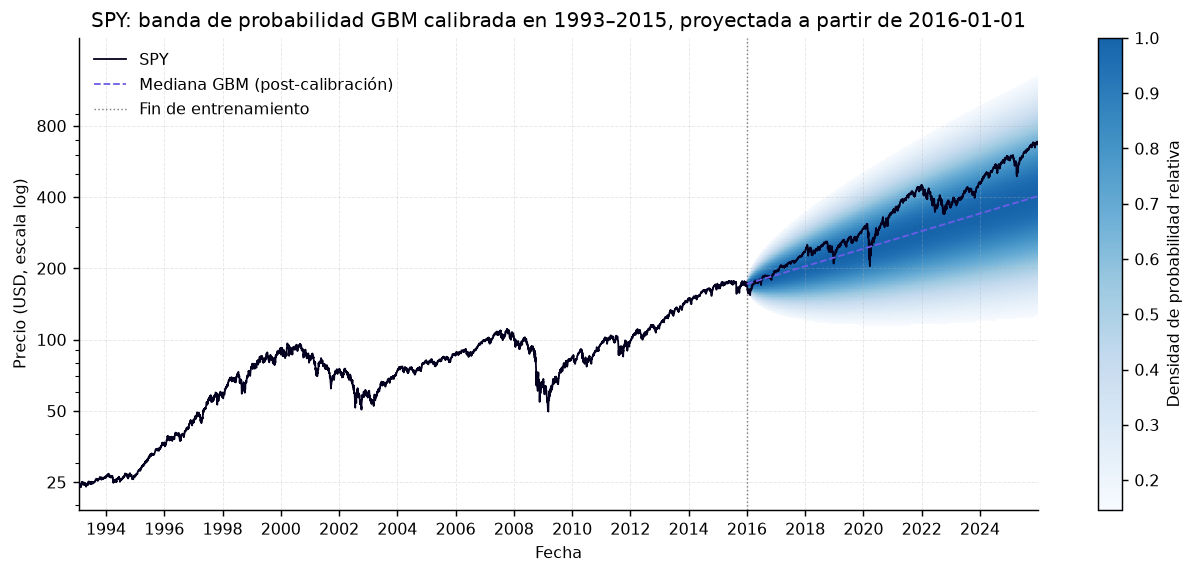

In [7]:
# --- Mapa de densidad relativa (heatmap), para la intuición visual -----------
mu_t = np.log(S0) + drift_geo * t_grid
sigma_t = sigma_est * np.sqrt(t_grid)
sigma_t[0] = 1e-8

n_price_bins = 200
log_grid = np.linspace(stats.norm.ppf(0.005, mu_t, sigma_t).min(),
                       stats.norm.ppf(0.995, mu_t, sigma_t).max(),
                       n_price_bins)
density = stats.norm.pdf(log_grid[None, :], loc=mu_t[:, None], scale=sigma_t[:, None])
density /= np.where(density.max(axis=1, keepdims=True) == 0, 1, density.max(axis=1, keepdims=True))

outside_95 = (log_grid[None, :] < np.log(bands[0.025])[:, None]) | \
             (log_grid[None, :] > np.log(bands[0.975])[:, None])
density_masked = ma.masked_where(outside_95, density)

cmap = mcolors.ListedColormap(plt.cm.Blues(np.linspace(0, 0.8, 256)))
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
x_dates = mdates.date2num(test_price.index.to_numpy())
mesh = ax.pcolormesh(x_dates, np.exp(log_grid), density_masked.T,
                      cmap=cmap, shading="gouraud", zorder=1)
fig.colorbar(mesh, ax=ax, label="Densidad de probabilidad relativa")

ax.plot(price.index, price.values, linewidth=1, color="#02001E",
        label=TICKER, zorder=5)
ax.plot(test_price.index, median_path, linestyle="--", linewidth=1,
        color="#6C5CE7", label="Mediana GBM (post-calibración)", zorder=5)
ax.axvline(price.loc[:split_idx].index[-1], color="gray", lw=0.8, ls=":",
           label="Fin de entrenamiento")

ax.set_yscale("log")
ax.set_yticks([25, 50, 100, 200, 400, 800])
formatter = mticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(price.index[0], price.index[-1])
ax.set_ylabel("Precio (USD, escala log)")
ax.set_xlabel("Fecha")
ax.set_title(f"{TICKER}: banda de probabilidad GBM calibrada en "
             f"{train_ret.index[0]:%Y}–{train_ret.index[-1]:%Y}, proyectada a partir de "
             f"{SPLIT_DATE}")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. Cobertura empírica de las bandas

Una forma cuantitativa —no sólo visual— de poner a prueba el modelo: si el GBM calibrado fuera
correcto, el precio observado debería caer dentro de la banda central del $p\%$ exactamente el
$p\%$ de los días hábiles del período de validación. Se lo compara contra el 50 %, 80 % y 95 %
nominal.

In [8]:
coverage = pd.DataFrame(
    {
        "Banda nominal": ["50%", "80%", "95%"],
        "Cobertura empírica": [
            ((test_price.values >= bands[0.25]) & (test_price.values <= bands[0.75])).mean(),
            ((test_price.values >= bands[0.10]) & (test_price.values <= bands[0.90])).mean(),
            ((test_price.values >= bands[0.025]) & (test_price.values <= bands[0.975])).mean(),
        ],
    }
)
coverage["Cobertura empírica"] = coverage["Cobertura empírica"].map("{:.1%}".format)
coverage

,Banda nominal,Cobertura empírica
0,50%,70.7%
1,80%,99.1%
2,95%,99.7%


## 6. Estacionariedad: $\mu$ y $\sigma$ en ventana móvil

El GBM supone $\mu$ y $\sigma$ constantes en el tiempo. Se los reestima en una ventana móvil de
60 días (~3 meses, fijado en `ROLLING_WINDOW`) sobre toda la serie y se los compara contra el valor
estático (ajustado una sola vez, con toda la muestra): si el modelo fuera correcto, la curva local
debería oscilar sin tendencia alrededor de la línea estática. No es lo que se observa.

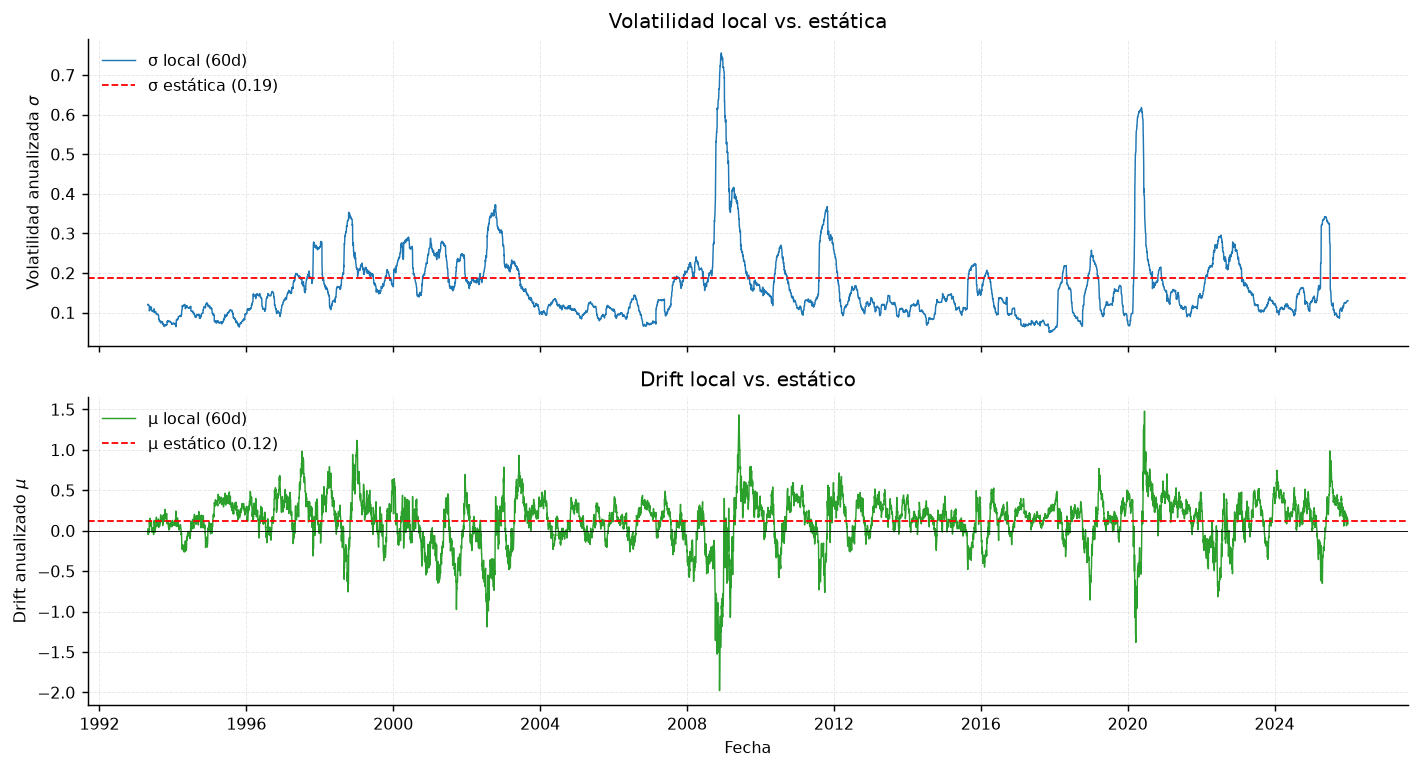

σ local — mín 0.05, máx 0.76  (estática: 0.19)
μ local — mín -1.98, máx 1.48  (estático: 0.12, cambia incluso de signo)


In [9]:
rolling_geo  = log_ret.rolling(ROLLING_WINDOW).mean() * TRADING_DAYS
rolling_sigma = log_ret.rolling(ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS)
rolling_drift = rolling_geo + 0.5 * rolling_sigma ** 2   # corrección de Itô local

static_sigma = log_ret.std() * np.sqrt(TRADING_DAYS)
static_drift = log_ret.mean() * TRADING_DAYS + 0.5 * static_sigma ** 2

fig, (ax_sigma, ax_drift) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax_sigma.plot(rolling_sigma.index, rolling_sigma.values, linewidth=0.8, color="#1f77b4",
              label=f"σ local ({ROLLING_WINDOW}d)")
ax_sigma.axhline(static_sigma, color="red", ls="--", lw=1.0,
                  label=f"σ estática ({static_sigma:.2f})")
ax_sigma.set_ylabel(r"Volatilidad anualizada $\sigma$")
ax_sigma.set_title("Volatilidad local vs. estática")
ax_sigma.legend(loc="upper left")

ax_drift.plot(rolling_drift.index, rolling_drift.values, linewidth=0.8, color="#2ca02c",
              label=f"μ local ({ROLLING_WINDOW}d)")
ax_drift.axhline(static_drift, color="red", ls="--", lw=1.0,
                  label=f"μ estático ({static_drift:.2f})")
ax_drift.axhline(0, color="black", lw=0.5)
ax_drift.set_ylabel(r"Drift anualizado $\mu$")
ax_drift.set_xlabel("Fecha")
ax_drift.set_title("Drift local vs. estático")
ax_drift.legend(loc="upper left")

plt.tight_layout()
plt.show()

print(f"σ local — mín {rolling_sigma.min():.2f}, máx {rolling_sigma.max():.2f}  "
      f"(estática: {static_sigma:.2f})")
print(f"μ local — mín {rolling_drift.min():.2f}, máx {rolling_drift.max():.2f}  "
      f"(estático: {static_drift:.2f}, cambia incluso de signo)")

## 7. Drift vs. volatilidad

El GBM asume $\mu$ y $\sigma$ independientes. Si estuvieran correlacionados —en particular, si la
volatilidad sube cuando el drift cae (el *efecto apalancamiento* de Black, 1976: una caída de precio
aumenta el ratio deuda/equity y con él el riesgo percibido)— el modelo de parámetros constantes e
independientes pierde justificación incluso localmente.

Se usa el mismo par de series de la Sección 6 ($\mu_t$, $\sigma_t$ en ventana móvil) y se calcula
su correlación de Pearson. El color del panel izquierdo codifica el tiempo, para ver si la relación
es estable o dominada por un puñado de episodios (2008, 2020).

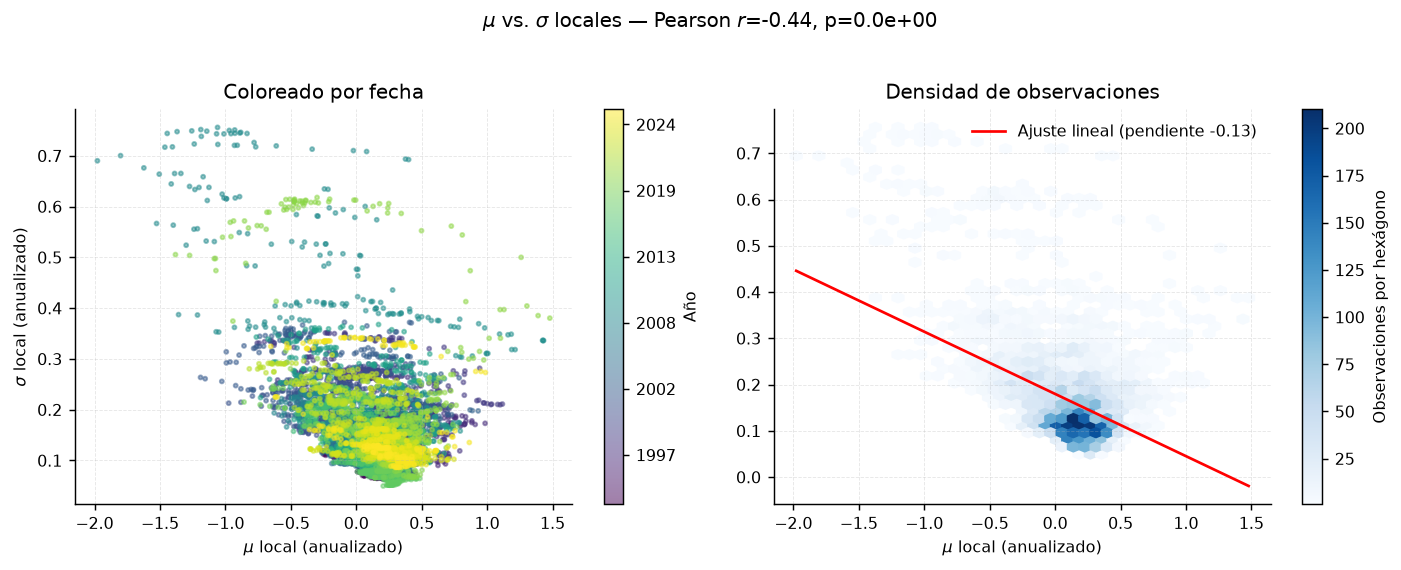

In [10]:
valid = rolling_drift.notna() & rolling_sigma.notna()
drift_v = rolling_drift[valid].to_numpy(dtype=float)
sigma_v = rolling_sigma[valid].to_numpy(dtype=float)
dates_v = mdates.date2num(rolling_drift[valid].index.to_numpy())

r, p_value = stats.pearsonr(drift_v, sigma_v)
slope, intercept = np.polyfit(drift_v, sigma_v, 1)

fig, (ax_time, ax_density) = plt.subplots(1, 2, figsize=(11, 4.2))

sc = ax_time.scatter(drift_v, sigma_v, c=dates_v, cmap="viridis", s=5, alpha=0.5)
cbar = fig.colorbar(sc, ax=ax_time)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))
cbar.set_label("Año")
ax_time.set_xlabel(r"$\mu$ local (anualizado)")
ax_time.set_ylabel(r"$\sigma$ local (anualizado)")
ax_time.set_title("Coloreado por fecha")

hb = ax_density.hexbin(drift_v, sigma_v, gridsize=40, cmap="Blues", mincnt=1)
fig.colorbar(hb, ax=ax_density, label="Observaciones por hexágono")
x_fit = np.linspace(drift_v.min(), drift_v.max(), 100)
ax_density.plot(x_fit, slope * x_fit + intercept, color="red", lw=1.5,
                 label=f"Ajuste lineal (pendiente {slope:.2f})")
ax_density.set_xlabel(r"$\mu$ local (anualizado)")
ax_density.set_title("Densidad de observaciones")
ax_density.legend(loc="upper right")

fig.suptitle(rf"$\mu$ vs. $\sigma$ locales — Pearson $r$={r:.2f}, p={p_value:.1e}", y=1.03)
plt.tight_layout()
plt.show()

## 8. Resumen

In [11]:
summary = pd.DataFrame(
    [
        ("σ constante",
         f"rango local [{rolling_sigma.min():.2f}, {rolling_sigma.max():.2f}] vs. "
         f"estática {static_sigma:.2f}", "Rechazada"),
        ("μ constante",
         f"rango local [{rolling_drift.min():.2f}, {rolling_drift.max():.2f}], "
         "cambia de signo", "Rechazada"),
        ("μ, σ independientes",
         f"Pearson r={r:.2f} (p={p_value:.1e})",
         "Rechazada" if p_value < ALPHA else "No rechazada"),
        ("Cobertura empírica ≈ nominal",
         ", ".join(coverage["Cobertura empírica"]),
         "Ver tabla Sección 5"),
    ],
    columns=["Hipótesis del GBM", "Evidencia", "Veredicto"],
)
summary

,Hipótesis del GBM,Evidencia,Veredicto
0,σ constante,"rango local [0.05, 0.76] vs. estática 0.19",Rechazada
1,μ constante,"rango local [-1.98, 1.48], cambia de signo",Rechazada
2,"μ, σ independientes",Pearson r=-0.44 (p=0.0e+00),Rechazada
3,Cobertura empírica ≈ nominal,"70.7%, 99.1%, 99.7%",Ver tabla Sección 5


### Conclusiones

1. La distribución exacta de $S_t$ bajo GBM calibrado captura razonablemente el orden de magnitud
   del rango de precios, pero la cobertura empírica de las bandas se aparta de la nominal — el
   modelo subestima el riesgo en los extremos (consistente con las colas pesadas documentadas en
   `SPY_caracterizacion.ipynb`).
2. Tanto $\mu$ como $\sigma$ varían sustancialmente en el tiempo: la hipótesis de parámetros
   constantes no se sostiene ni siquiera en ventanas de pocos meses.
3. La relación entre drift y volatilidad locales es consistente con un efecto apalancamiento
   (drift bajo ⟷ volatilidad alta), lo que viola también la independencia asumida entre ambos.

En conjunto, el GBM de parámetros constantes funciona como *benchmark* — es la distribución nula
frente a la que se contrastan modelos con volatilidad estocástica o condicional (ARCH/GARCH,
Heston) — pero no como descripción adecuada de SPY.

---

### Referencias

- Osborne, M. F. M. (1959). *Brownian Motion in the Stock Market*. Operations Research, 7(2).
- Black, F., Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3).
- Merton, R. C. (1973). *Theory of Rational Option Pricing*. Bell Journal of Economics, 4(1).
- Black, F. (1976). *Studies of Stock Price Volatility Changes*. Proceedings of the ASA.
- Künsch, H. R. (1989). *The Jackknife and the Bootstrap for General Stationary Observations*. Annals of Statistics, 17(3).